#     **Global Layoffs Analysis**

#####**1) Defining Problem Statement**

In this project, we study the data in a tabular format using Python libraries like Pandas, NumPy, Matplotlib, and Seaborn. We explore, step by step, how global factors have led to layoffs — including how industry and market changes have driven them, which companies have laid off the most employees, how funding raised relates to layoffs, and more.

####**Key Question Raised-**
- Which country had the most layoffs?
- Which company had the most layoffs?
- What are the top 10 companies by layoffs, per year (2020–2023)?
- How did layoffs change over time (year by year)?
- Does funding raised relate to layoff size?
- What are the total layoffs per industry and funding stage?
- Which quarters had the most layoffs?

###**2) Collecting the data**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('layoffs.csv')

print(df.info()) #listing columns and types
df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2361 entries, 0 to 2360
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   company                2361 non-null   object 
 1   location               2361 non-null   object 
 2   industry               2357 non-null   object 
 3   total_laid_off         1621 non-null   float64
 4   percentage_laid_off    1576 non-null   float64
 5   date                   2360 non-null   object 
 6   stage                  2355 non-null   object 
 7   country                2361 non-null   object 
 8   funds_raised_millions  2152 non-null   float64
dtypes: float64(3), object(6)
memory usage: 166.1+ KB
None


,company,location,industry,total_laid_off,percentage_laid_off,date,stage,country,funds_raised_millions
0,Atlassian,Sydney,Other,500.0,0.05,3/6/2023,Post-IPO,Australia,210.0
1,SiriusXM,New York City,Media,475.0,0.08,3/6/2023,Post-IPO,United States,525.0
2,Alerzo,Ibadan,Retail,400.0,NaN,3/6/2023,Series B,Nigeria,16.0
3,UpGrad,Mumbai,Education,120.0,NaN,3/6/2023,Unknown,India,631.0
4,Loft,Sao Paulo,Real Estate,340.0,0.15,3/3/2023,Unknown,Brazil,788.0
5,Embark Trucks,SF Bay Area,Transportation,230.0,0.70,3/3/2023,Post-IPO,United States,317.0
6,Lendi,Sydney,Real Estate,100.0,NaN,3/3/2023,Unknown,Australia,59.0
7,UserTesting,SF Bay Area,Marketing,63.0,NaN,3/3/2023,Acquired,United States,152.0
8,Airbnb,SF Bay Area,NaN,30.0,NaN,3/3/2023,Post-IPO,United States,6400.0
9,Accolade,Seattle,Healthcare,NaN,NaN,3/3/2023,Post-IPO,United States,458.0


###**3) Data Cleaning And Manipulation**

In [ ]:
df.dropna(subset='total_laid_off', inplace=True)
df['funds_raised_millions'].fillna(df['funds_raised_millions'].median(), inplace=True)
df['industry']=df['industry'].str.replace(' ','')
df['industry'] = df['industry'].str.replace('CryptoCurrency','Crypto')
df[['location','company','country']] = df[['location', 'company','country']].apply(lambda x: x.str.lower().str.strip())
df.drop_duplicates(inplace=True)
df['date'] = pd.to_datetime(df['date'])

<small>We kept some null values in columns like `industry`, `percentage_laid_off`, `date`, and `stage`.
These nulls are minimal (1-3 rows for most, ~26% for percentage_laid_off) and dropping them would
remove otherwise valid data from other columns. They can be filtered out selectively at the point
of analysis, whenever a specific chart or aggregation depends on that column.</small>

###**4) Exploratory Data Analysis**

###**1. Which company has done most layoffs**

Text(0.5, 1.0, 'Total amount of layoffs by Companies (2020-2023)')

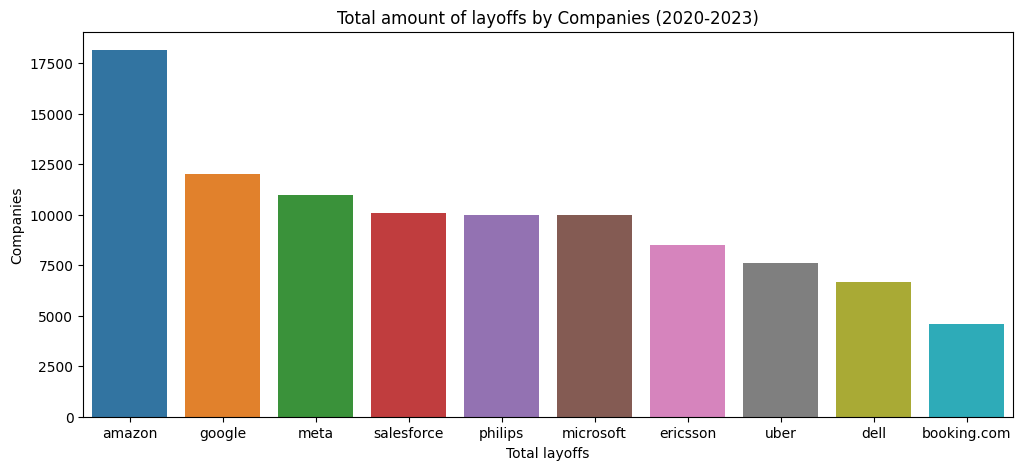

In [ ]:
plt.figure(figsize=(12,5))
most_layoffs_company=df.groupby('company')['total_laid_off'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=most_layoffs_company.index, y=most_layoffs_company.values, hue=most_layoffs_company.index)
plt.xlabel('Total layoffs')
plt.ylabel('Companies')
plt.title('Total amount of layoffs by Companies (2020-2023)')
plt.show()

**Amazon recorded the highest number of layoffs (18,000+), followed by a notable drop to Google (12,000+).**

###**2. Which industry got hit hardest overall?**

Text(0.5, 1.0, 'Total Layoffs by Industry (2020-2023)')

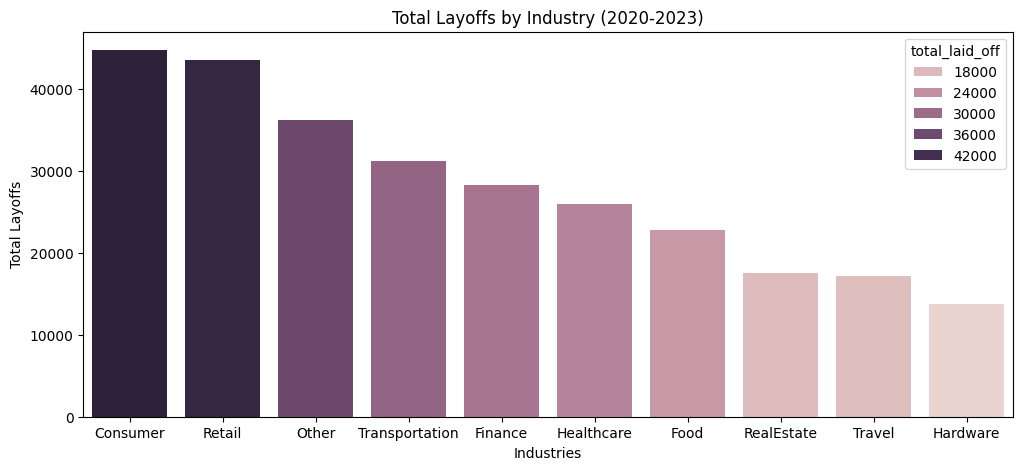

In [ ]:
total_layoffs_industry = df.groupby('industry')['total_laid_off'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,5))
sns.barplot(x=total_layoffs_industry.index, y=total_layoffs_industry.values, hue=total_layoffs_industry)
plt.xlabel('Industries')
plt.ylabel('Total Layoffs')
plt.title('Total Layoffs by Industry (2020-2023)')
plt.show()

<small>Consumer and Retail dominate total layoffs, together accounting for the largest share among all industries.
The "Other" category ranks third, but this is a limitation rather than a finding — it likely groups multiple
unclassified industries together, so its high total is expected rather than meaningful on its own.</small>

###**4. Which country had the most layoffs?**

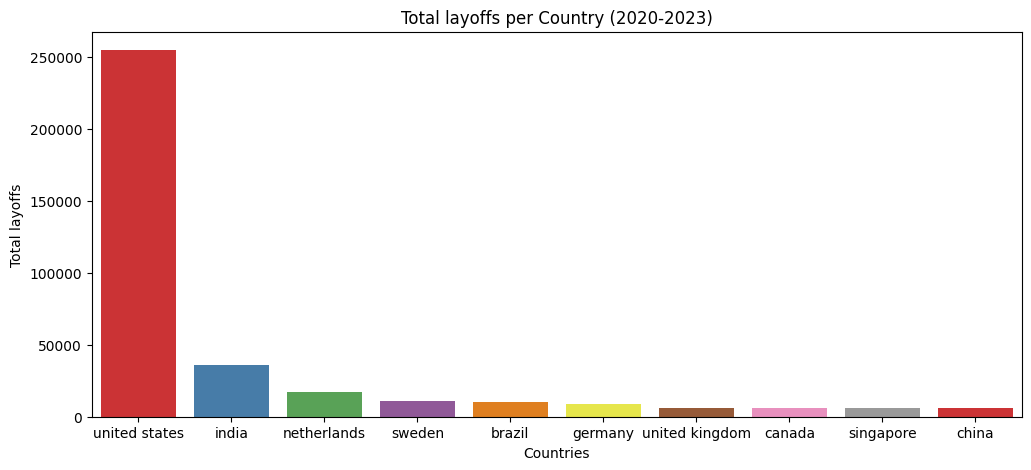

In [ ]:
most_layoffs_country = df.groupby('country')['total_laid_off'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,5))
sns.barplot(x=most_layoffs_country.index,y=most_layoffs_country.values, palette='Set1')
plt.xlabel('Countries')
plt.ylabel('Total layoffs')
plt.title('Total layoffs per Country (2020-2023)')
plt.show()

<small>United States recorded the highest number of layoffs between 2020-2023, followed by India (35,993) and other countries at a distance.</small>

###**5. How did layoffs change over time (year by year)**

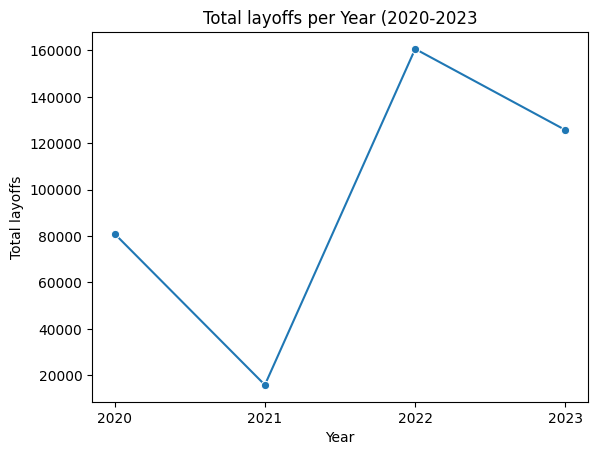

In [ ]:
df_dated=df.dropna(subset='date')
total_layoffs_year=df_dated.groupby(df_dated['date'].dt.year.astype(int))['total_laid_off'].sum().sort_values(ascending=False)
sns.lineplot(x=total_layoffs_year.index, y=total_layoffs_year.values,marker='o')
plt.xlabel('Year')
plt.ylabel('Total layoffs')
plt.xticks(total_layoffs_year.index)
plt.title('Total layoffs per Year (2020-2023')
plt.show()

<small>Layoffs dropped significantly in 2021, likely reflecting the initial economic recovery as markets adjusted
post-COVID-19. However, layoffs rose sharply again in 2022 and peaked, before slightly declining in 2023 —
this aligns with widely reported market corrections in the tech sector during that period, including
overhiring corrections, rising interest rates, and reduced venture funding.

**Note**: this dataset doesn't include company-stated reasons for layoffs, so this explanation is an
interpretation based on known macroeconomic events during this period, not something the data itself confirms.</small>

###**6. Which funding stage had the most layoffs?**

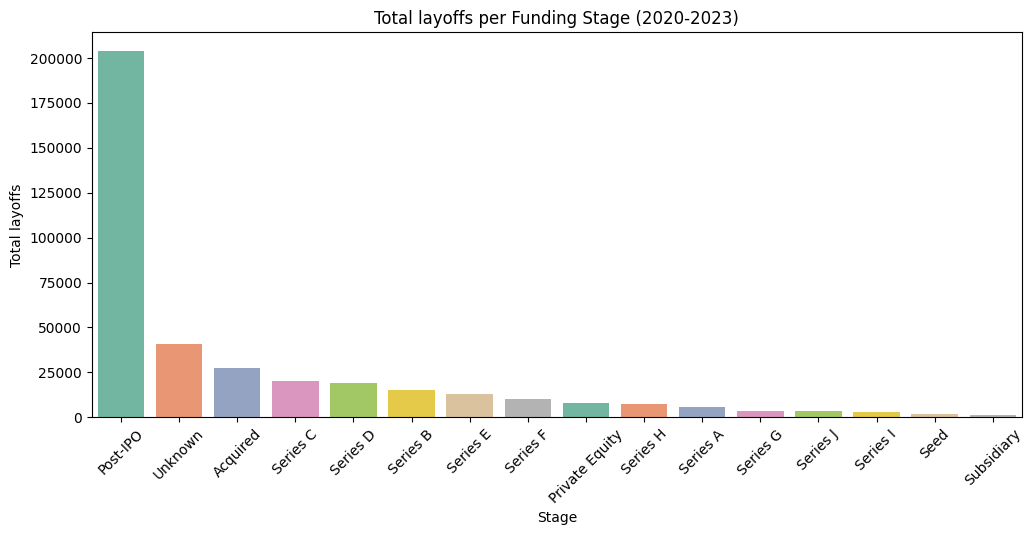

In [ ]:
total_layoffs_stage = df.groupby('stage')['total_laid_off'].sum().sort_values(ascending=False)
plt.figure(figsize=(12,5))
sns.barplot(x=total_layoffs_stage.index, y=total_layoffs_stage.values, palette='Set2')
plt.xlabel('Stage')
plt.ylabel('Total layoffs')
plt.title('Total layoffs per Funding Stage (2020-2023)')
plt.xticks(rotation=45)
plt.show()

<small>"Post-IPO" is the stage with the highest total layoffs, exceeding 200,000 — nearly five times the
next highest stage, "Unknown". Since "Unknown" reflects missing stage data rather than an
actual funding category, the more meaningful comparison is against "Acquired", the next
identifiable stage.</small>

###**7. Does funding raised relate to layoff size?**

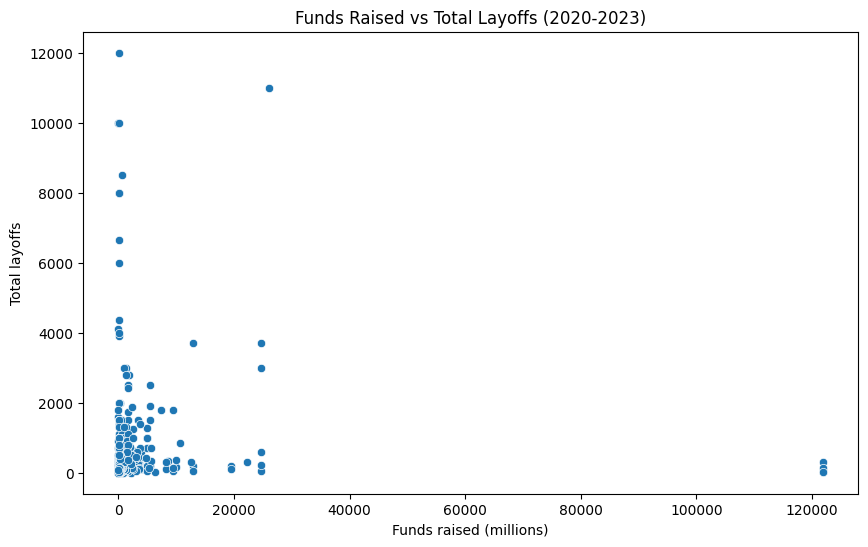

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='funds_raised_millions', y='total_laid_off', data=df)
plt.xlabel('Funds raised (millions)')
plt.ylabel('Total layoffs')
plt.title('Funds Raised vs Total Layoffs (2020-2023)')
plt.show()

<small>Most companies raised relatively modest funding (under 5,000 million), and layoff size doesn't show a
clear increasing pattern with more funds raised. One company stands out as a major outlier, having raised
over 120,000 million — far beyond any other company in the dataset — yet its total layoffs remain low,
reinforcing that higher funding doesn't necessarily correspond to higher layoffs.

Some of the highest layoff counts, on the other hand, came from companies with little to no disclosed
funding, further suggesting that funds raised alone isn't a strong predictor of layoff size in this dataset.</small>

###**8. Which quarter had the most layoffs?**

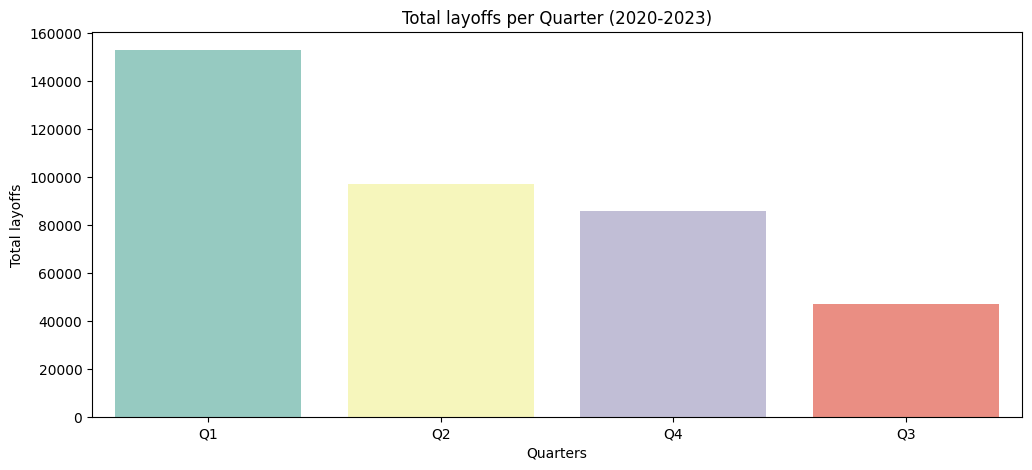

In [ ]:
df_dated['quarter']=df_dated['quarter'] = df_dated['date'].dt.quarter.astype(int)
df_dated['quarter'] = 'Q' + df_dated['quarter'].astype(str)
total_layoffs_quarter = df_dated.groupby('quarter')['total_laid_off'].sum().sort_values(ascending=False)
plt.figure(figsize=(12,5))
sns.barplot(x=total_layoffs_quarter.index, y=total_layoffs_quarter.values, palette='Set3')
plt.xlabel('Quarters')
plt.ylabel('Total layoffs')
plt.title('Total layoffs per Quarter (2020-2023)')
plt.show()

<small>The chart shows Q1 has the highest total layoffs across all years combined. This may align with the
start of a new fiscal year, when many companies reassess budgets, finalize cost-cutting plans, and
implement layoffs decided at the end of the previous year.</small>

###**9. What are the total layoffs per industry and funding stage?**

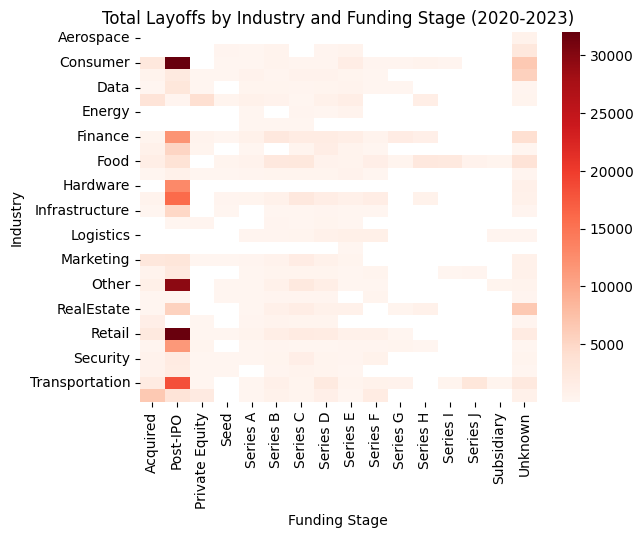

In [ ]:
pivot_tl=df.pivot_table(index='industry', columns='stage', values='total_laid_off', aggfunc='sum')
sns.heatmap(pivot_tl, cmap='Reds')
plt.xlabel('Funding Stage')
plt.ylabel('Industry')
plt.title('Total Layoffs by Industry and Funding Stage (2020-2023)')
plt.show()

<small>Retail and Consumer industries show the highest layoffs within the Post-IPO stage, reinforcing that
large, publicly listed companies in these sectors were hit hardest overall. The "Unknown" stage follows
next, but as noted earlier, this reflects missing stage data rather than a distinct funding category.</small>

###**10. What are the top 10 companies by total layoffs, per year (2020–2023)?**

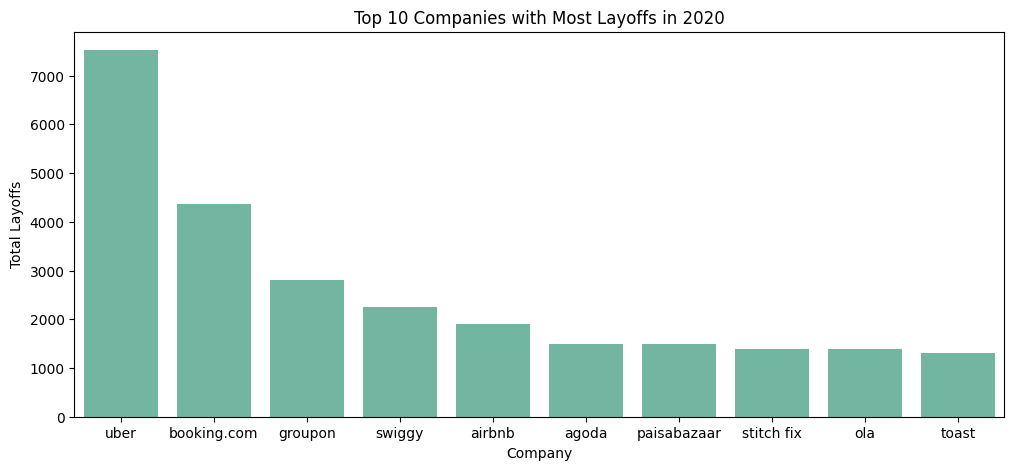

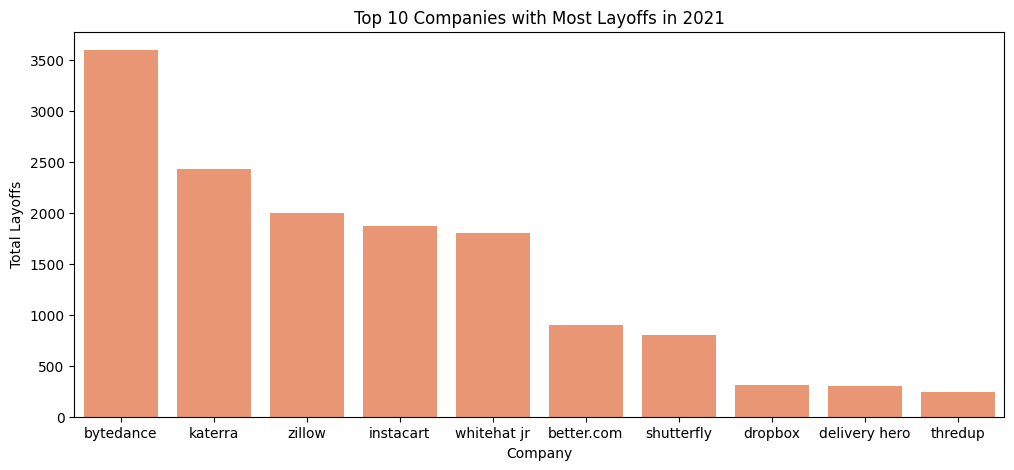

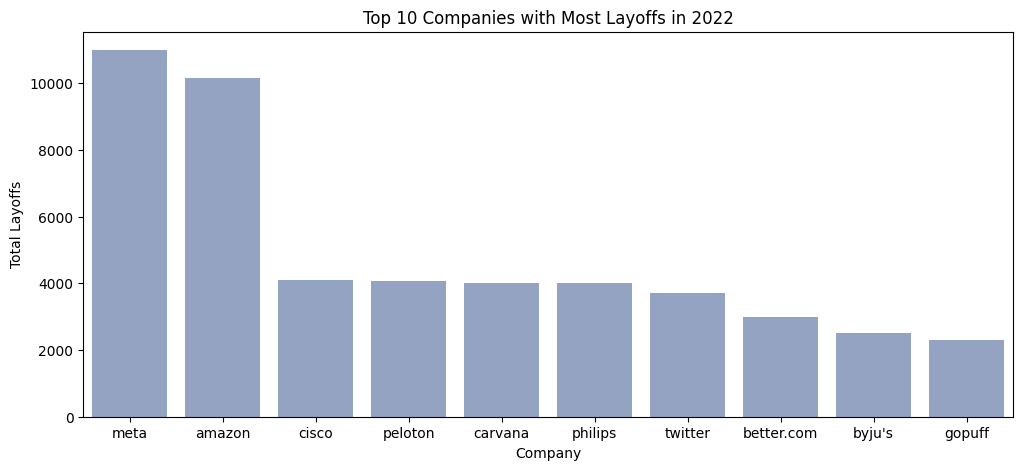

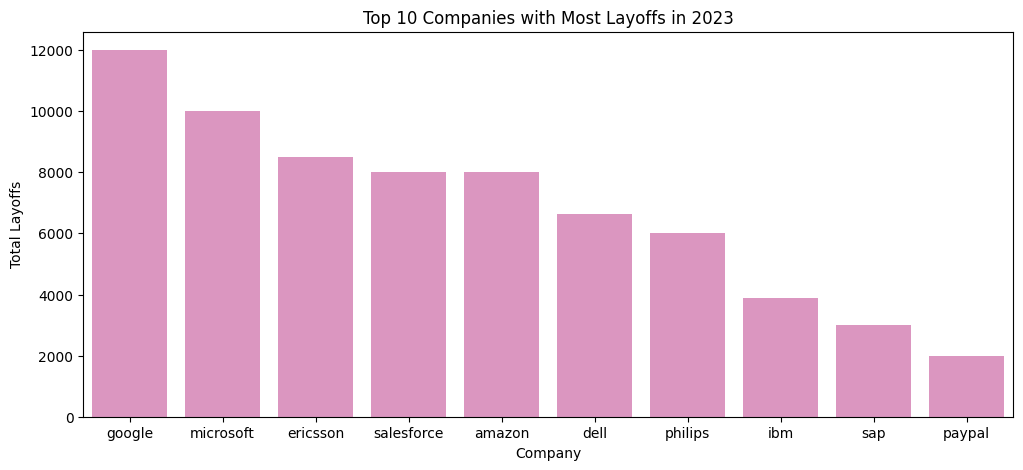

In [ ]:

years=df_dated['date'].dt.year.astype(int)
colors = sns.color_palette("Set2", 4)
for yr,color in zip([2020, 2021, 2022, 2023], colors):
  yearly_data = df_dated[df_dated['date'].dt.year == yr]
  top_companies = (yearly_data.groupby('company')['total_laid_off'].sum().sort_values(ascending=False).head(10))
  plt.figure(figsize=(12,5))
  sns.barplot(x=top_companies.index, y=top_companies.values, color=color)
  plt.title(f'Top 10 Companies with Most Layoffs in {yr}')
  plt.xlabel('Company')
  plt.ylabel('Total Layoffs')
  plt.show()
  print("\n")

<small>**2020 (COVID shock)**: Uber tops the list at 7,000+ layoffs, with Booking.com, Groupon, and Swiggy following. The pattern is dominated by travel, hospitality, and gig-economy companies — direct casualties of pandemic lockdowns and travel bans.</small>

<small>**2021 (uneven recovery)**: ByteDance leads (3,000+), alongside Katerra, Zillow, and Instacart. Layoff totals are noticeably lower than 2020 across the board — a sign of partial recovery — but real estate/construction (Katerra) and proptech (Zillow) show up, hinting at sector-specific struggles even as the broader economy stabilized.

**2022 (tech correction begins)**: Meta and Amazon jump to the top with 10,000+ layoffs each — a sharp scale increase from 2021. This marks the start of the post-pandemic tech pullback, as companies that over-hired during the 2020–21 boom began correcting.</small>

<small>**2023 (correction deepens)**: Google leads at ~12,000+, followed by Microsoft, Ericsson, Salesforce, and Amazon. Layoff scale is the highest across all four years, and the sector mix broadens beyond "big tech" into telecom (Ericsson) and enterprise software (Salesforce) — suggesting the correction spread wider through the tech-adjacent economy.</small>